In [32]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize

In [2]:
assets = ["SPY", "QQQ", "TLT", "GLD", "BTC-USD"]

In [3]:
prices = yf.download(
    assets,
    start="2020-01-01",
    auto_adjust=True
)["Close"]

[*********************100%***********************]  5 of 5 completed


In [4]:
arithmetic_returns = prices.pct_change()

log_returns = np.log(
    prices / prices.shift(1)
)

C:\Users\abish\AppData\Local\Temp\ipykernel_28844\630540574.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  arithmetic_returns = prices.pct_change()


In [5]:
print(prices.head())

print(arithmetic_returns.head())

print(log_returns.head())

Ticker          BTC-USD         GLD         QQQ         SPY         TLT
Date                                                                   
2020-01-01  7200.174316         NaN         NaN         NaN         NaN
2020-01-02  6985.470215  143.949997  208.317520  296.888123  113.746468
2020-01-03  7344.884277  145.860001  206.409363  294.640015  115.498245
2020-01-04  7410.656738         NaN         NaN         NaN         NaN
2020-01-05  7411.317383         NaN         NaN         NaN         NaN
Ticker       BTC-USD       GLD      QQQ       SPY       TLT
Date                                                       
2020-01-01       NaN       NaN      NaN       NaN       NaN
2020-01-02 -0.029819       NaN      NaN       NaN       NaN
2020-01-03  0.051452  0.013269 -0.00916 -0.007572  0.015401
2020-01-04  0.008955  0.000000  0.00000  0.000000  0.000000
2020-01-05  0.000089  0.000000  0.00000  0.000000  0.000000
Ticker       BTC-USD       GLD       QQQ       SPY       TLT
Date           

In [6]:
prices = prices.dropna()

arithmetic_returns = prices.pct_change().dropna()

log_returns = np.log(
    prices / prices.shift(1)
).dropna()

In [7]:
print(prices.head())

print(arithmetic_returns.head())

print(log_returns.head())

Ticker          BTC-USD         GLD         QQQ         SPY         TLT
Date                                                                   
2020-01-02  6985.470215  143.949997  208.317520  296.888123  113.746468
2020-01-03  7344.884277  145.860001  206.409363  294.640015  115.498245
2020-01-06  7769.219238  147.389999  207.739349  295.764130  114.842323
2020-01-07  8163.692383  147.970001  207.710388  294.932495  114.277817
2020-01-08  8079.862793  146.860001  209.271637  296.504395  113.522362
Ticker       BTC-USD       GLD       QQQ       SPY       TLT
Date                                                        
2020-01-03  0.051452  0.013269 -0.009160 -0.007572  0.015401
2020-01-06  0.057773  0.010490  0.006443  0.003815 -0.005679
2020-01-07  0.050774  0.003935 -0.000139 -0.002812 -0.004915
2020-01-08 -0.010269 -0.007502  0.007516  0.005330 -0.006611
2020-01-09 -0.024851 -0.005652  0.008473  0.006781  0.003510
Ticker       BTC-USD       GLD       QQQ       SPY       TLT
Date    

In [8]:
mean_returns = arithmetic_returns.mean()

volatility = arithmetic_returns.std()

covariance_matrix = arithmetic_returns.cov()

correlation_matrix = arithmetic_returns.corr()

In [9]:
print("Mean Returns")
print(mean_returns)

print("\nVolatility")
print(volatility)

print("\nCovariance Matrix")
print(covariance_matrix)

print("\nCorrelation Matrix")
print(correlation_matrix)

Mean Returns
Ticker
BTC-USD    0.002240
GLD        0.000723
QQQ        0.000878
SPY        0.000647
TLT       -0.000142
dtype: float64

Volatility
Ticker
BTC-USD    0.038303
GLD        0.011385
QQQ        0.015719
SPY        0.012849
TLT        0.010560
dtype: float64

Covariance Matrix
Ticker    BTC-USD       GLD       QQQ       SPY       TLT
Ticker                                                   
BTC-USD  0.001467  0.000055  0.000235  0.000187 -0.000010
GLD      0.000055  0.000130  0.000027  0.000020  0.000025
QQQ      0.000235  0.000027  0.000247  0.000189 -0.000010
SPY      0.000187  0.000020  0.000189  0.000165 -0.000015
TLT     -0.000010  0.000025 -0.000010 -0.000015  0.000112

Correlation Matrix
Ticker    BTC-USD       GLD       QQQ       SPY       TLT
Ticker                                                   
BTC-USD  1.000000  0.126790  0.390052  0.379766 -0.024653
GLD      0.126790  1.000000  0.150216  0.138367  0.206798
QQQ      0.390052  0.150216  1.000000  0.936808 -0.062

In [10]:
weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2])

In [11]:
portfolio_return = np.dot(
    weights,
    mean_returns
)

print(portfolio_return)

0.0008691291489275894


In [12]:
portfolio_variance = np.dot(
    weights.T,
    np.dot(covariance_matrix, weights)
)

portfolio_volatility = np.sqrt(portfolio_variance)

print(portfolio_variance)

print(portfolio_volatility)

0.00014103552120167778
0.011875837705260113


In [13]:
annualized_return = portfolio_return * 252

annualized_volatility = portfolio_volatility * np.sqrt(252)

print("Annualized Return")
print(annualized_return)

print("\nAnnualized Volatility")
print(annualized_volatility)

Annualized Return
0.21902054552975253

Annualized Volatility
0.18852307907209345


In [14]:
risk_free_rate = 0.02

sharpe_ratio = (
    annualized_return - risk_free_rate
) / annualized_volatility

print("Sharpe Ratio")

print(sharpe_ratio)

Sharpe Ratio
1.0556826597004854


In [15]:
portfolio_daily_returns = arithmetic_returns.dot(weights)

cumulative_returns = (
    1 + portfolio_daily_returns
).cumprod()

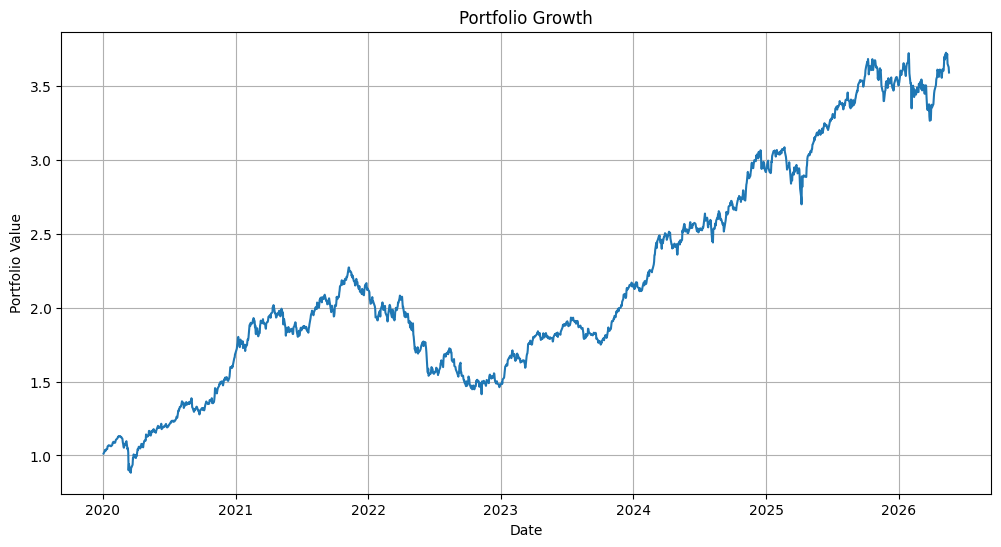

In [16]:
plt.figure(figsize=(12,6))

plt.plot(cumulative_returns)

plt.title("Portfolio Growth")

plt.xlabel("Date")

plt.ylabel("Portfolio Value")

plt.grid(True)

plt.show()

In [17]:
rolling_max = cumulative_returns.cummax()

drawdown = (
    cumulative_returns - rolling_max
) / rolling_max

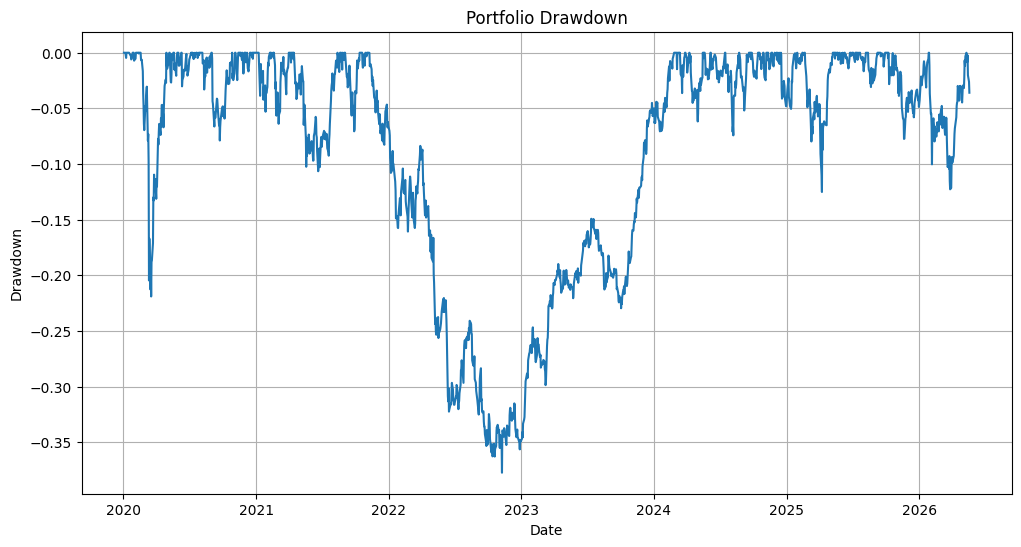

In [18]:
plt.figure(figsize=(12,6))

plt.plot(drawdown)

plt.title("Portfolio Drawdown")

plt.xlabel("Date")

plt.ylabel("Drawdown")

plt.grid(True)

plt.show()

In [19]:
max_drawdown = drawdown.min()

print("Maximum Drawdown")

print(max_drawdown)

Maximum Drawdown
-0.37744817012298437


In [20]:
years = len(portfolio_daily_returns) / 252

ending_value = cumulative_returns.iloc[-1]

cagr = (
    ending_value ** (1 / years)
) - 1

print("CAGR")

print(cagr)

CAGR
0.22272773865725815


In [21]:
calmar_ratio = cagr / abs(max_drawdown)

print("Calmar Ratio")

print(calmar_ratio)

Calmar Ratio
0.590088272476421


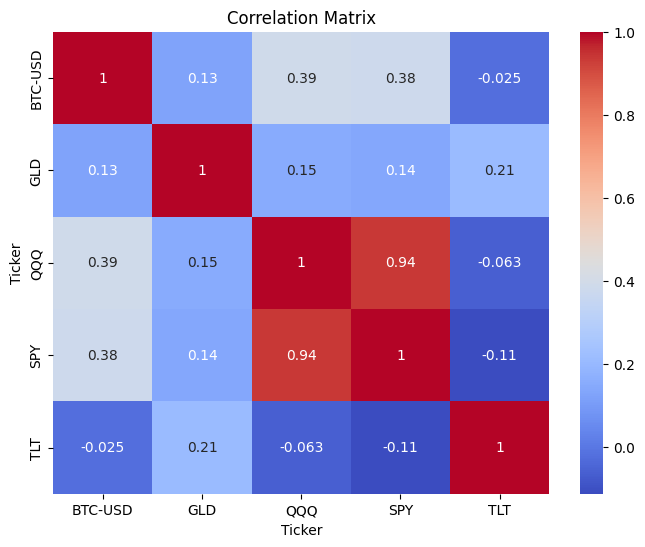

In [24]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [25]:
num_portfolios = 5000

results = []

for _ in range(num_portfolios):

    weights = np.random.random(len(assets))

    weights = weights / np.sum(weights)

    portfolio_return = np.dot(
        weights,
        mean_returns
    ) * 252

    portfolio_volatility = np.sqrt(
        np.dot(
            weights.T,
            np.dot(covariance_matrix * 252, weights)
        )
    )

    sharpe_ratio = (
        portfolio_return - 0.02
    ) / portfolio_volatility

    results.append([
        portfolio_return,
        portfolio_volatility,
        sharpe_ratio
    ])

In [26]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Return",
        "Volatility",
        "Sharpe"
    ]
)

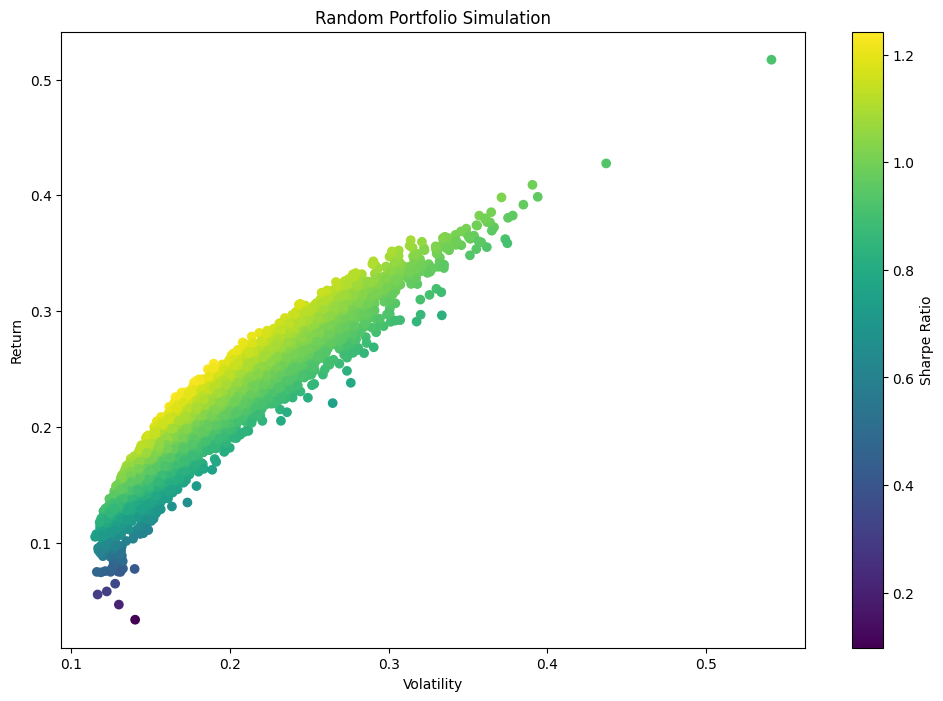

In [27]:
plt.figure(figsize=(12,8))

scatter = plt.scatter(
    results_df["Volatility"],
    results_df["Return"],
    c=results_df["Sharpe"],
    cmap="viridis"
)

plt.xlabel("Volatility")

plt.ylabel("Return")

plt.title("Random Portfolio Simulation")

plt.colorbar(scatter, label="Sharpe Ratio")

plt.show()

In [28]:
max_sharpe_idx = results_df["Sharpe"].idxmax()

max_sharpe_portfolio = results_df.iloc[max_sharpe_idx]

print(max_sharpe_portfolio)

Return        0.225878
Volatility    0.165677
Sharpe        1.242640
Name: 1027, dtype: float64


In [29]:
num_portfolios = 5000

results = []

weights_record = []

for _ in range(num_portfolios):

    weights = np.random.random(len(assets))

    weights = weights / np.sum(weights)

    weights_record.append(weights)

    portfolio_return = np.dot(
        weights,
        mean_returns
    ) * 252

    portfolio_volatility = np.sqrt(
        np.dot(
            weights.T,
            np.dot(covariance_matrix * 252, weights)
        )
    )

    sharpe_ratio = (
        portfolio_return - 0.02
    ) / portfolio_volatility

    results.append([
        portfolio_return,
        portfolio_volatility,
        sharpe_ratio
    ])

In [30]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Return",
        "Volatility",
        "Sharpe"
    ]
)

In [31]:
max_sharpe_idx = results_df["Sharpe"].idxmax()

optimal_weights = weights_record[max_sharpe_idx]

for asset, weight in zip(assets, optimal_weights):

    print(asset, weight)

SPY 0.16461044026992513
QQQ 0.6056807166674769
TLT 0.0812509602718383
GLD 0.14718075943119996
BTC-USD 0.001277123359559736


In [33]:
def portfolio_performance(
    weights,
    mean_returns,
    covariance_matrix
):

    portfolio_return = np.dot(
        weights,
        mean_returns
    ) * 252

    portfolio_volatility = np.sqrt(
        np.dot(
            weights.T,
            np.dot(
                covariance_matrix * 252,
                weights
            )
        )
    )

    return portfolio_return, portfolio_volatility

In [34]:
def negative_sharpe_ratio(
    weights,
    mean_returns,
    covariance_matrix,
    risk_free_rate=0.02
):

    portfolio_return, portfolio_volatility = portfolio_performance(
        weights,
        mean_returns,
        covariance_matrix
    )

    sharpe_ratio = (
        portfolio_return - risk_free_rate
    ) / portfolio_volatility

    return -sharpe_ratio

In [35]:
constraints = ({
    "type": "eq",
    "fun": lambda w: np.sum(w) - 1
})

In [36]:
bounds = tuple(
    (0, 1)
    for asset in assets
)

In [37]:
initial_weights = np.array(
    len(assets) * [1 / len(assets)]
)

In [38]:
optimized_result = minimize(
    negative_sharpe_ratio,
    initial_weights,
    args=(
        mean_returns,
        covariance_matrix
    ),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

In [39]:
optimal_weights = optimized_result.x

for asset, weight in zip(
    assets,
    optimal_weights
):

    print(asset, weight)

SPY 0.14712066292229253
QQQ 0.5945599431207487
TLT 0.25831939395695896
GLD 4.8955602285594325e-18
BTC-USD 0.0


In [40]:
optimized_return, optimized_volatility = portfolio_performance(
    optimal_weights,
    mean_returns,
    covariance_matrix
)

optimized_sharpe = (
    optimized_return - 0.02
) / optimized_volatility

print("Optimized Return")
print(optimized_return)

print("\nOptimized Volatility")
print(optimized_volatility)

print("\nOptimized Sharpe")
print(optimized_sharpe)

Optimized Return
0.24849739060523804

Optimized Volatility
0.1808860675870135

Optimized Sharpe
1.2632116649632044


In [41]:
rolling_volatility = (
    portfolio_daily_returns
    .rolling(window=60)
    .std()
    * np.sqrt(252)
)

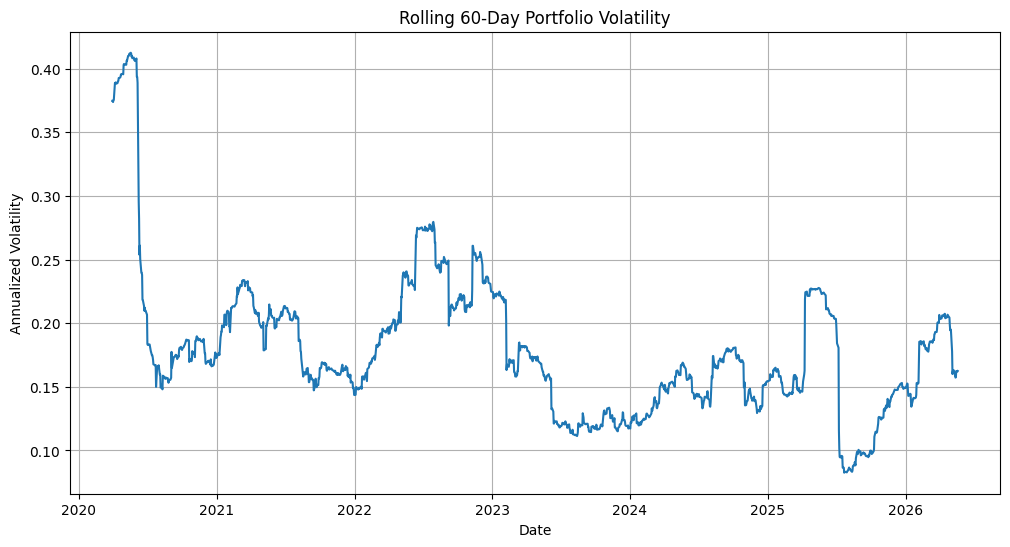

In [42]:
plt.figure(figsize=(12,6))

plt.plot(rolling_volatility)

plt.title("Rolling 60-Day Portfolio Volatility")

plt.xlabel("Date")

plt.ylabel("Annualized Volatility")

plt.grid(True)

plt.show()

In [43]:
rolling_return = (
    portfolio_daily_returns
    .rolling(window=60)
    .mean()
    * 252
)

rolling_vol = (
    portfolio_daily_returns
    .rolling(window=60)
    .std()
    * np.sqrt(252)
)

rolling_sharpe = (
    rolling_return - 0.02
) / rolling_vol

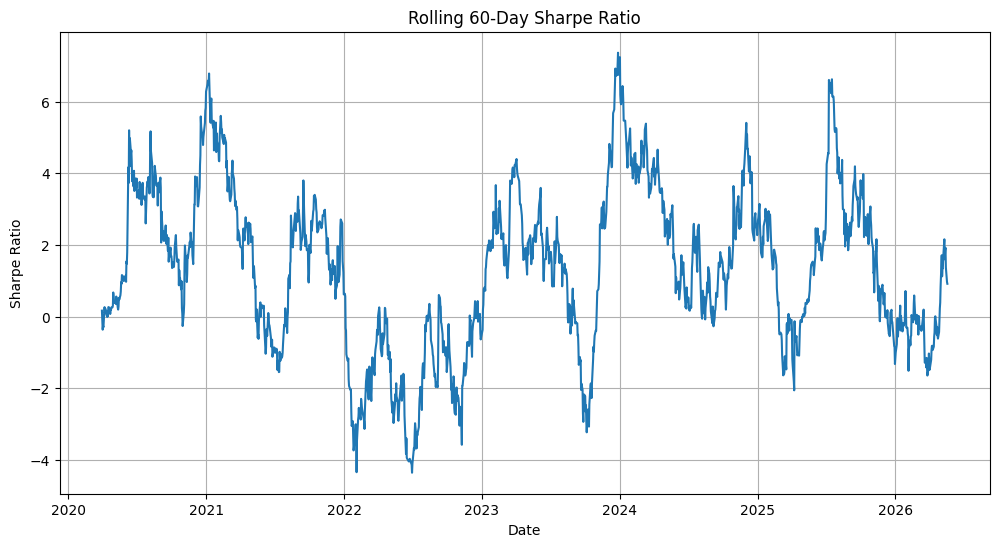

In [44]:
plt.figure(figsize=(12,6))

plt.plot(rolling_sharpe)

plt.title("Rolling 60-Day Sharpe Ratio")

plt.xlabel("Date")

plt.ylabel("Sharpe Ratio")

plt.grid(True)

plt.show()

In [45]:
rolling_corr = (
    arithmetic_returns["SPY"]
    .rolling(window=60)
    .corr(arithmetic_returns["TLT"])
)

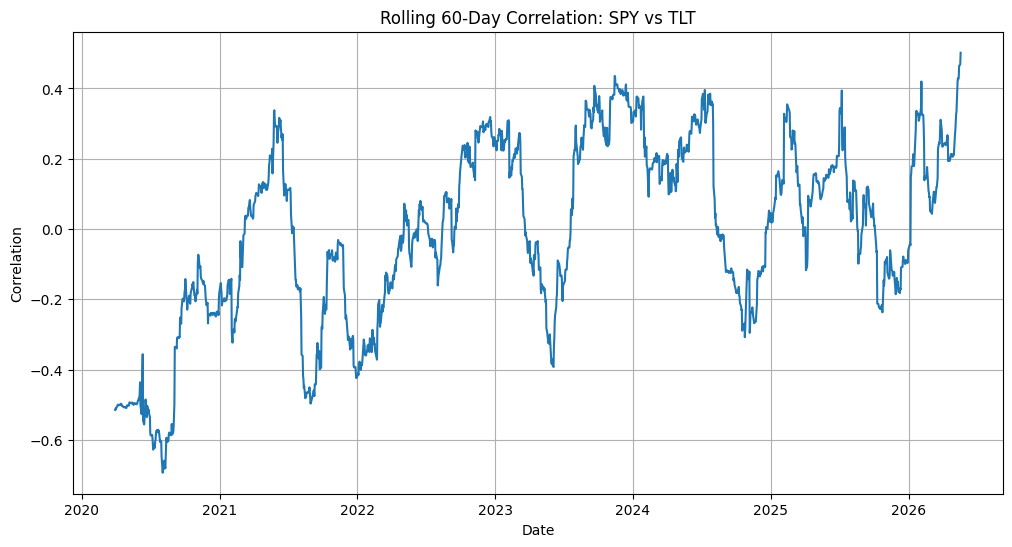

In [46]:
plt.figure(figsize=(12,6))

plt.plot(rolling_corr)

plt.title("Rolling 60-Day Correlation: SPY vs TLT")

plt.xlabel("Date")

plt.ylabel("Correlation")

plt.grid(True)

plt.show()

In [47]:
perturbed_mean_returns = mean_returns.copy()

perturbed_mean_returns["QQQ"] *= 0.95

In [48]:
perturbed_result = minimize(
    negative_sharpe_ratio,
    initial_weights,
    args=(
        perturbed_mean_returns,
        covariance_matrix
    ),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

In [49]:
perturbed_weights = perturbed_result.x

for asset, weight in zip(
    assets,
    perturbed_weights
):

    print(asset, weight)

SPY 0.15508064816000047
QQQ 0.6117048778346215
TLT 0.23321447400537854
GLD 0.0
BTC-USD 0.0


In [50]:
perturbed_mean_returns = mean_returns.copy()

perturbed_mean_returns["QQQ"] *= 0.70

In [51]:
perturbed_result = minimize(
    negative_sharpe_ratio,
    initial_weights,
    args=(
        perturbed_mean_returns,
        covariance_matrix
    ),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

In [52]:
perturbed_weights = perturbed_result.x

for asset, weight in zip(
    assets,
    perturbed_weights
):

    print(asset, weight)

SPY 0.15713686768390284
QQQ 0.6042748689301011
TLT 1.704778246211684e-16
GLD 0.23858826338599606
BTC-USD 0.0


In [53]:
def portfolio_volatility(
    weights,
    covariance_matrix
):

    return np.sqrt(
        np.dot(
            weights.T,
            np.dot(
                covariance_matrix * 252,
                weights
            )
        )
    )

In [54]:
target_returns = np.linspace(
    0.05,
    0.35,
    50
)

In [55]:
efficient_volatilities = []

efficient_weights = []

for target_return in target_returns:

    constraints = (

        {
            "type": "eq",
            "fun": lambda w: (
                np.dot(w, mean_returns) * 252
            ) - target_return
        },

        {
            "type": "eq",
            "fun": lambda w: np.sum(w) - 1
        }

    )

    result = minimize(
        portfolio_volatility,
        initial_weights,
        args=(covariance_matrix,),
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )

    efficient_volatilities.append(result.fun)

    efficient_weights.append(result.x)

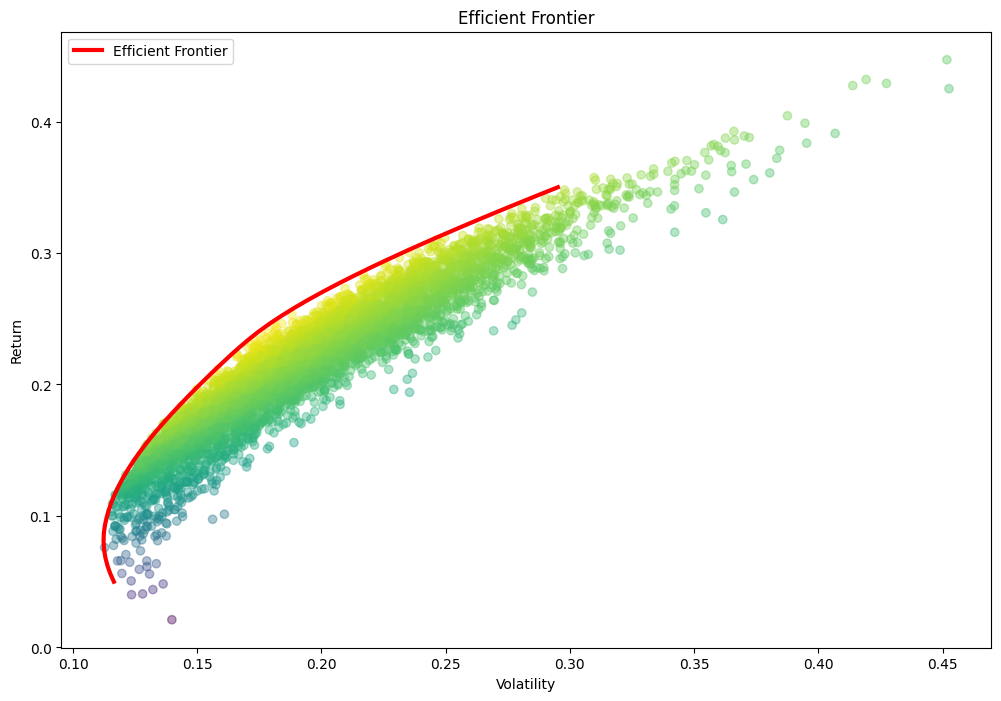

In [56]:
plt.figure(figsize=(12,8))

plt.plot(
    efficient_volatilities,
    target_returns,
    color="red",
    linewidth=3,
    label="Efficient Frontier"
)

plt.scatter(
    results_df["Volatility"],
    results_df["Return"],
    c=results_df["Sharpe"],
    cmap="viridis",
    alpha=0.4
)

plt.xlabel("Volatility")

plt.ylabel("Return")

plt.title("Efficient Frontier")

plt.legend()

plt.show()

In [57]:
inverse_volatility_weights = (
    1 / volatility
)

inverse_volatility_weights = (
    inverse_volatility_weights
    / inverse_volatility_weights.sum()
)

print(inverse_volatility_weights)

Ticker
BTC-USD    0.074575
GLD        0.250901
QQQ        0.181721
SPY        0.222300
TLT        0.270504
dtype: float64


In [58]:
rp_return = np.dot(
    inverse_volatility_weights,
    mean_returns
) * 252

rp_volatility = np.sqrt(
    np.dot(
        inverse_volatility_weights.T,
        np.dot(
            covariance_matrix * 252,
            inverse_volatility_weights
        )
    )
)

rp_sharpe = (
    rp_return - 0.02
) / rp_volatility

print("Risk Parity Return")
print(rp_return)

print("\nRisk Parity Volatility")
print(rp_volatility)

print("\nRisk Parity Sharpe")
print(rp_sharpe)

Risk Parity Return
0.15456585812904627

Risk Parity Volatility
0.13798220102773587

Risk Parity Sharpe
0.9752406986318267


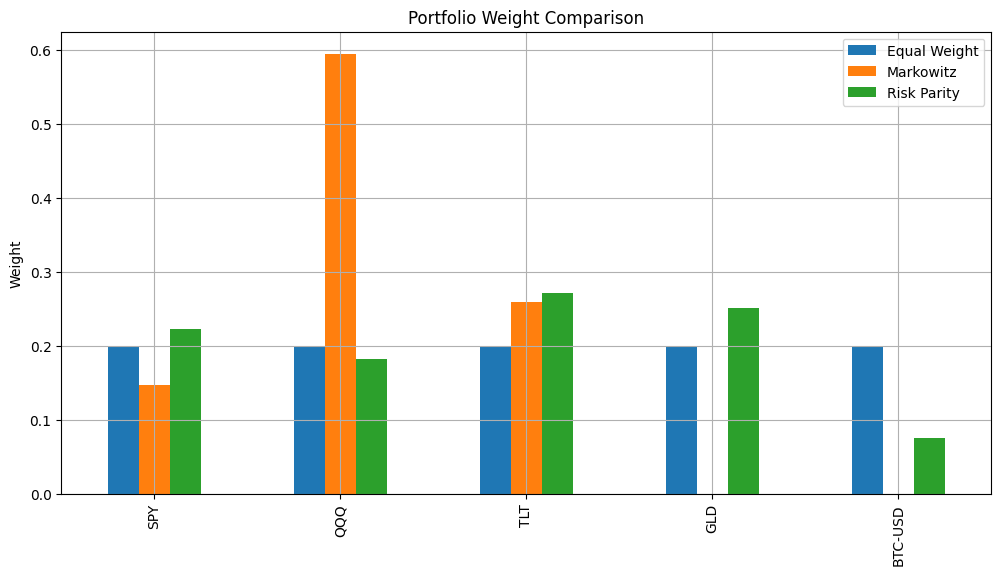

In [59]:
comparison_df = pd.DataFrame({

    "Equal Weight":
        np.repeat(
            1 / len(assets),
            len(assets)
        ),

    "Markowitz":
        optimal_weights,

    "Risk Parity":
        inverse_volatility_weights

}, index=assets)

comparison_df.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Portfolio Weight Comparison")

plt.ylabel("Weight")

plt.grid(True)

plt.show()

In [60]:
split_date = "2023-01-01"

train_returns = arithmetic_returns.loc[
    arithmetic_returns.index < split_date
]

test_returns = arithmetic_returns.loc[
    arithmetic_returns.index >= split_date
]

In [61]:
train_mean_returns = train_returns.mean()

train_covariance_matrix = train_returns.cov()

In [62]:
train_result = minimize(
    negative_sharpe_ratio,
    initial_weights,
    args=(
        train_mean_returns,
        train_covariance_matrix
    ),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

In [63]:
train_weights = train_result.x

for asset, weight in zip(
    assets,
    train_weights
):

    print(asset, weight)

SPY 0.44041834213789244
QQQ 0.5322136780514765
TLT 0.0
GLD 0.02736797981063124
BTC-USD 1.856971140374834e-17


In [64]:
test_portfolio_returns = test_returns.dot(
    train_weights
)

test_cumulative_returns = (
    1 + test_portfolio_returns
).cumprod()

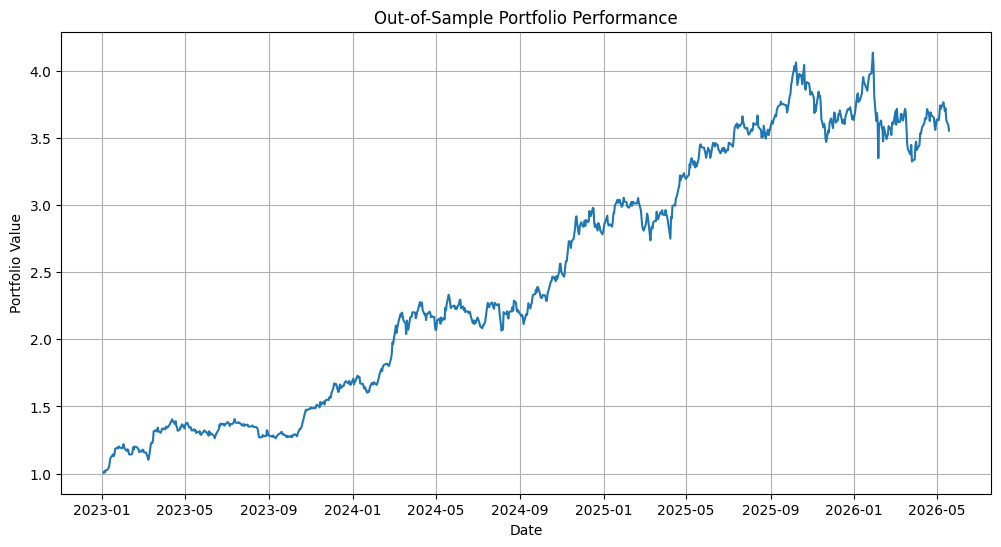

In [65]:
plt.figure(figsize=(12,6))

plt.plot(test_cumulative_returns)

plt.title("Out-of-Sample Portfolio Performance")

plt.xlabel("Date")

plt.ylabel("Portfolio Value")

plt.grid(True)

plt.show()

In [66]:
lookback_window = 252

rebalance_frequency = 21

In [67]:
rolling_returns = []

rolling_dates = []

In [68]:
for start_idx in range(

    lookback_window,

    len(arithmetic_returns) - rebalance_frequency,

    rebalance_frequency
):

    train_window = arithmetic_returns.iloc[
        start_idx - lookback_window : start_idx
    ]

    test_window = arithmetic_returns.iloc[
        start_idx : start_idx + rebalance_frequency
    ]

    rolling_mean_returns = train_window.mean()

    rolling_covariance_matrix = train_window.cov()

    result = minimize(

        negative_sharpe_ratio,

        initial_weights,

        args=(
            rolling_mean_returns,
            rolling_covariance_matrix
        ),

        method="SLSQP",

        bounds=bounds,

        constraints=constraints
    )

    rolling_weights = result.x

    portfolio_test_returns = test_window.dot(
        rolling_weights
    )

    rolling_returns.extend(
        portfolio_test_returns.values
    )

    rolling_dates.extend(
        portfolio_test_returns.index
    )

In [69]:
rolling_returns_series = pd.Series(
    rolling_returns,
    index=rolling_dates
)

In [70]:
rolling_cumulative_returns = (
    1 + rolling_returns_series
).cumprod()

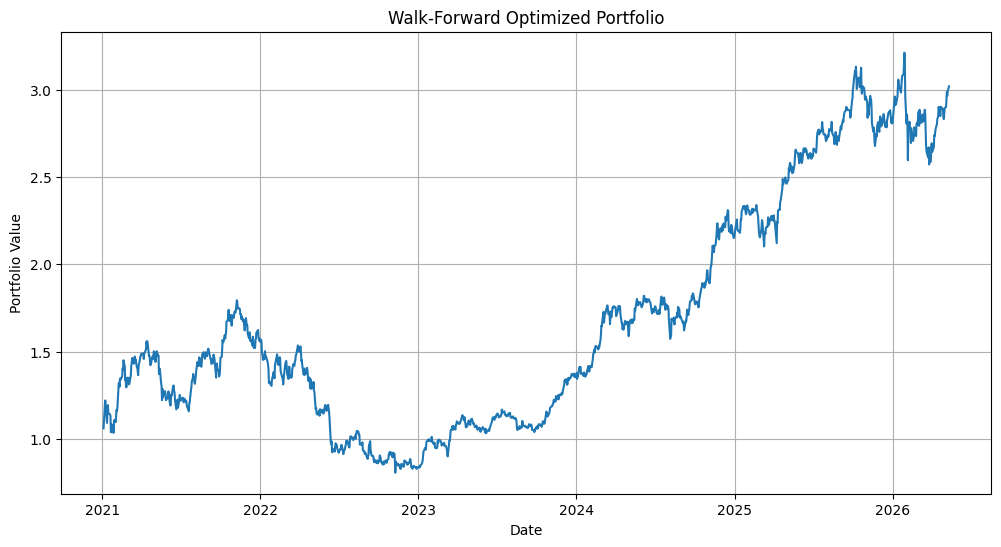

In [71]:
plt.figure(figsize=(12,6))

plt.plot(rolling_cumulative_returns)

plt.title("Walk-Forward Optimized Portfolio")

plt.xlabel("Date")

plt.ylabel("Portfolio Value")

plt.grid(True)

plt.show()

In [72]:
future_returns = (
    arithmetic_returns["SPY"]
    .shift(-1)
)

In [73]:
cheating_strategy_returns = np.where(

    future_returns > 0,

    arithmetic_returns["SPY"],

    -arithmetic_returns["SPY"]

)

In [74]:
cheating_strategy_returns = pd.Series(
    cheating_strategy_returns,
    index=arithmetic_returns.index
)

In [75]:
cheating_cumulative_returns = (
    1 + cheating_strategy_returns
).cumprod()

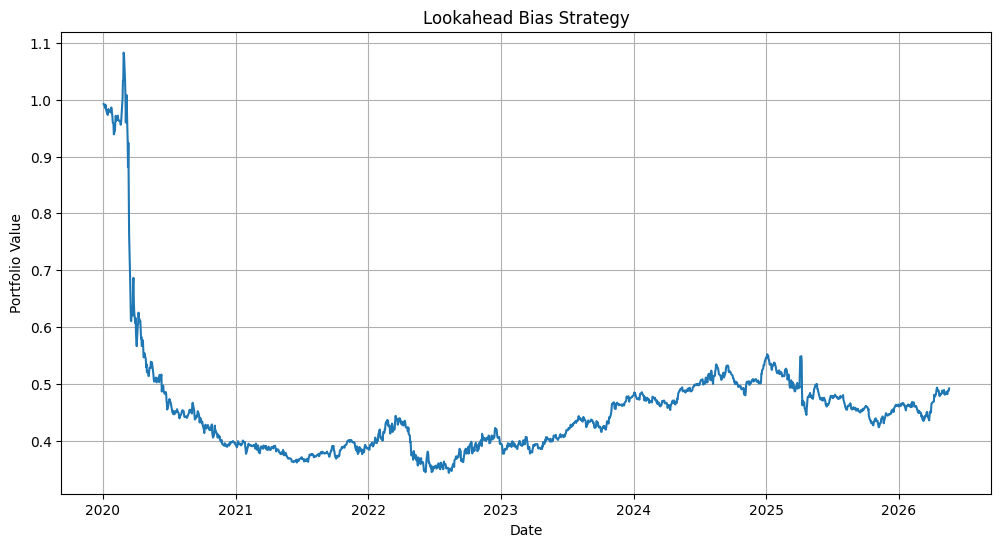

In [76]:
plt.figure(figsize=(12,6))

plt.plot(cheating_cumulative_returns)

plt.title("Lookahead Bias Strategy")

plt.xlabel("Date")

plt.ylabel("Portfolio Value")

plt.grid(True)

plt.show()

In [77]:
perfect_signal = np.sign(
    arithmetic_returns["SPY"].shift(-1)
)

In [78]:
perfect_strategy_returns = (
    perfect_signal
    * arithmetic_returns["SPY"]
)

In [79]:
perfect_strategy_returns = (
    perfect_strategy_returns
    .dropna()
)

In [80]:
perfect_cumulative_returns = (
    1 + perfect_strategy_returns
).cumprod()

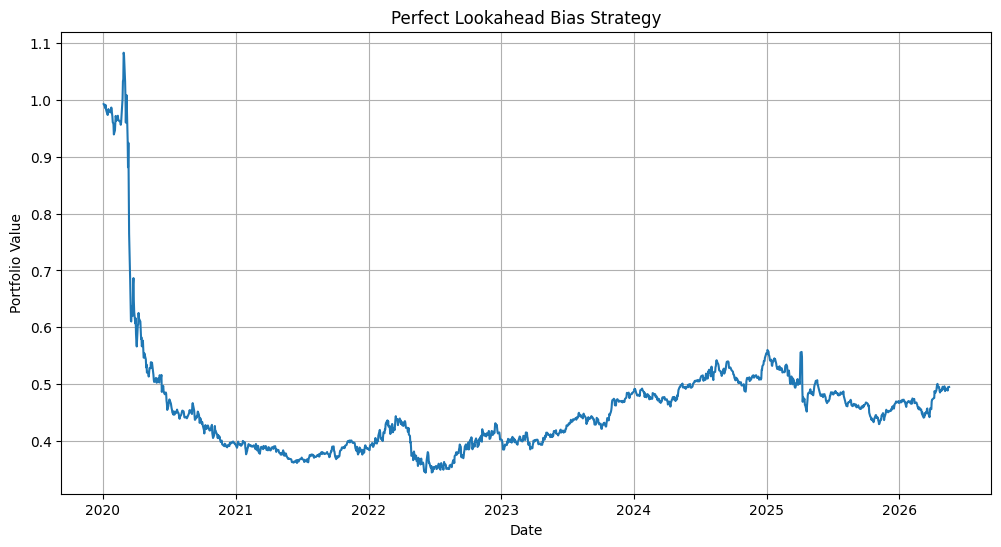

In [81]:
plt.figure(figsize=(12,6))

plt.plot(perfect_cumulative_returns)

plt.title("Perfect Lookahead Bias Strategy")

plt.xlabel("Date")

plt.ylabel("Portfolio Value")

plt.grid(True)

plt.show()

In [82]:
future_spy_returns = (
    arithmetic_returns["SPY"]
    .shift(-1)
)

In [83]:
perfect_strategy_returns = np.abs(
    future_spy_returns
)

In [84]:
perfect_strategy_returns = (
    perfect_strategy_returns
    .dropna()
)

In [85]:
perfect_cumulative_returns = (
    1 + perfect_strategy_returns
).cumprod()

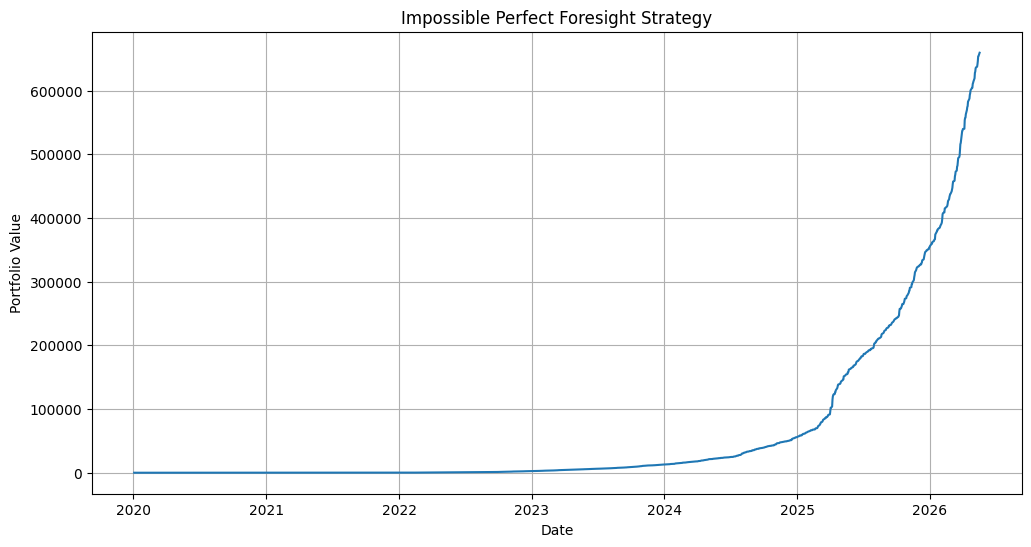

In [86]:
plt.figure(figsize=(12,6))

plt.plot(perfect_cumulative_returns)

plt.title("Impossible Perfect Foresight Strategy")

plt.xlabel("Date")

plt.ylabel("Portfolio Value")

plt.grid(True)

plt.show()

In [87]:
np.random.seed(42)

random_signal = np.random.randn(
    len(arithmetic_returns)
)

In [88]:
random_positions = np.sign(
    random_signal
)

In [89]:
random_strategy_returns = (
    random_positions
    * arithmetic_returns["SPY"]
)

In [90]:
random_cumulative_returns = (
    1 + random_strategy_returns
).cumprod()

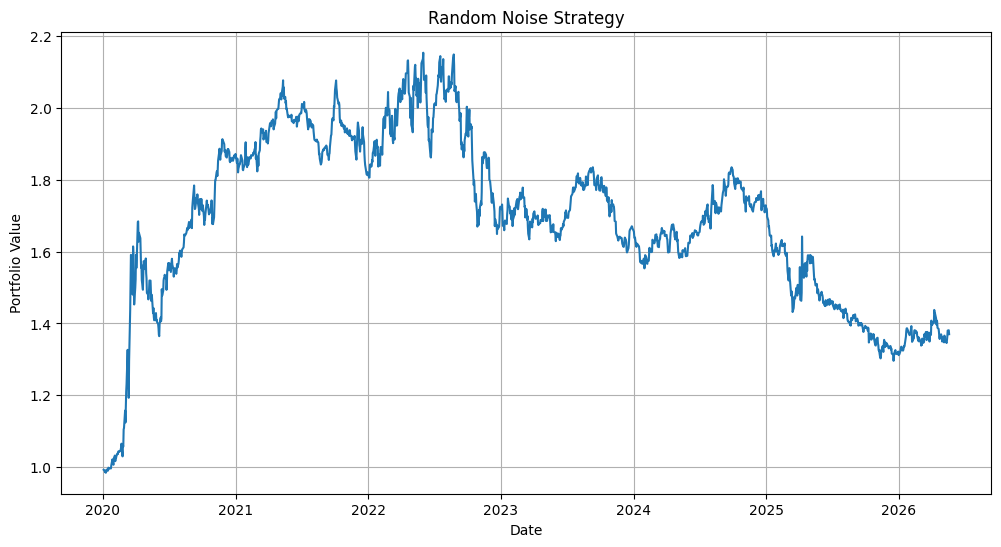

In [91]:
plt.figure(figsize=(12,6))

plt.plot(random_cumulative_returns)

plt.title("Random Noise Strategy")

plt.xlabel("Date")

plt.ylabel("Portfolio Value")

plt.grid(True)

plt.show()

In [92]:
momentum_signal = (
    prices
    .pct_change(126)
)

In [93]:
print(momentum_signal.tail())

Ticker       BTC-USD       GLD       QQQ       SPY       TLT
Date                                                        
2026-05-13 -0.252079  0.137745  0.149709  0.095528 -0.031728
2026-05-14 -0.213075  0.124622  0.160973  0.101655 -0.034777
2026-05-15 -0.222278  0.081090  0.144359  0.087797 -0.050786
2026-05-18 -0.228123  0.092877  0.163183  0.105374 -0.044071
2026-05-19 -0.191670  0.097856  0.147905  0.096785 -0.046410


In [94]:
momentum_ranks = (
    momentum_signal
    .rank(axis=1)
)

In [95]:
print(momentum_ranks.tail())

Ticker      BTC-USD  GLD  QQQ  SPY  TLT
Date                                   
2026-05-13      1.0  4.0  5.0  3.0  2.0
2026-05-14      1.0  4.0  5.0  3.0  2.0
2026-05-15      1.0  3.0  5.0  4.0  2.0
2026-05-18      1.0  3.0  5.0  4.0  2.0
2026-05-19      1.0  4.0  5.0  3.0  2.0


In [96]:
best_asset = momentum_signal.idxmax(axis=1)

C:\Users\abish\AppData\Local\Temp\ipykernel_28844\4263475305.py:1: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  best_asset = momentum_signal.idxmax(axis=1)


In [99]:
momentum_returns = []

for date in arithmetic_returns.index:

    asset = best_asset.loc[date]

    if pd.isna(asset):
        momentum_returns.append(0)
    else:
        momentum_returns.append(
            arithmetic_returns.loc[date, asset]
        )

In [100]:
momentum_returns = pd.Series(
    momentum_returns,
    index=arithmetic_returns.index
)

In [101]:
momentum_cumulative_returns = (
    1 + momentum_returns
).cumprod()

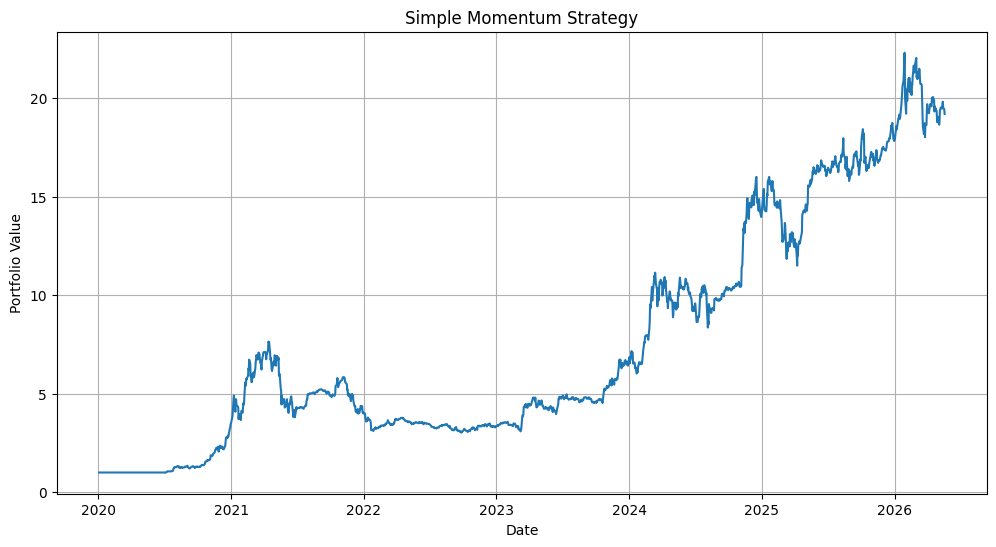

In [102]:
plt.figure(figsize=(12,6))

plt.plot(momentum_cumulative_returns)

plt.title("Simple Momentum Strategy")

plt.xlabel("Date")

plt.ylabel("Portfolio Value")

plt.grid(True)

plt.show()